# Tüdőrák predikciója vizelet LC–MS metabolomikai profilból

### feature selection és gépi tanulási modellek összehasonlítása

### Ambrus Csaba


## 0. Setup

In [1]:
BRANCH = "cursor/metabolomics-ml-benchmark-tf-mlp"

from google.colab import drive
drive.mount('/content/drive')

%cd /content
import os
if not os.path.exists("/content/MetabolKD/.git"):
    !git clone --branch {BRANCH} --single-branch https://github.com/csambrus/MetabolKD.git
else:
    %cd /content/MetabolKD
    !git fetch origin {BRANCH}
    !git checkout {BRANCH}
    !git pull origin {BRANCH}

%cd /content/MetabolKD
%pip install -r ./requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content
/content/MetabolKD
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.66 MiB | 11.66 MiB/s, done.
From https://github.com/csambrus/MetabolKD
 * branch            cursor/metabolomics-ml-benchmark-tf-mlp -> FETCH_HEAD
   2738bbd..935fcaf  cursor/metabolomics-ml-benchmark-tf-mlp -> origin/cursor/metabolomics-ml-benchmark-tf-mlp
Already on 'cursor/metabolomics-ml-benchmark-tf-mlp'
Your branch is behind 'origin/cursor/metabolomics-ml-benchmark-tf-mlp' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
From https://github.com/csambrus/MetabolKD
 * branch            cursor/metabolomics-ml-benchmark-tf-mlp -> FETCH_HEAD
Updating 2738bbd..935f

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = "content/MetabolKD"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
from src.runtime_setup import setup_tensorflow_runtime, setup_notebook_error_logger, set_global_seed

set_global_seed()
setup_notebook_error_logger()
setup_tensorflow_runtime()


PROJECT_ROOT: content/MetabolKD
Globalis seed beallitva: 42
✅ Globális hiba-logger aktív.
TF version: 2.20.0
GPUs:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPU cores:  12
CUDA_VISIBLE_DEVICES = None
TF version = 2.20.0
Built with CUDA = True
GPUs = [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical GPUs = [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU matmul done in 0.1539444923400879 sec


12

## 1. Adatbetöltés


In [3]:
from src.download_dataset import download_dataset, combine_pos_neg_to_feature_matrix

data = download_dataset()
X, meta = combine_pos_neg_to_feature_matrix(data)

# ML célváltozó
target_col = "class_label"  # Lung cancer vs Control

# Csak címkézett minták
mask = meta[target_col].notna()
X = X.loc[mask].copy()
meta = meta.loc[mask].copy()

# Biztonság: indexek egyezzenek
meta = meta.reindex(X.index)

X_raw = X
y = meta[target_col]

print("X_raw:", X_raw.shape)
print(y.value_counts(dropna=False))

DATA_DIR: megvan /content/MetabolKD/data/MTBLS28
MTBLS28 raw:
  sample:    (2010, 27)
  assay_pos: (1005, 35)
  assay_neg: (1005, 35)
  maf_pos:   (1807, 1026)
  maf_neg:   (1359, 1026)
POS feature matrix: (1005, 1807)
NEG feature matrix: (1005, 1359)
Combined feature matrix: (1005, 3166)
Csoportok:
class_label
Control        536
Lung cancer    469
Name: count, dtype: int64
X_raw: (1005, 3166)
class_label
Control        536
Lung cancer    469
Name: count, dtype: int64


## 2. QC és preprocessing

       total_signal  n_missing  missing_frac
count  1.005000e+03     1005.0        1005.0
mean   7.478392e+06        0.0           0.0
std    4.417414e+05        0.0           0.0
min    5.207632e+06        0.0           0.0
25%    7.231368e+06        0.0           0.0
50%    7.506417e+06        0.0           0.0
75%    7.774351e+06        0.0           0.0
max    8.636358e+06        0.0           0.0


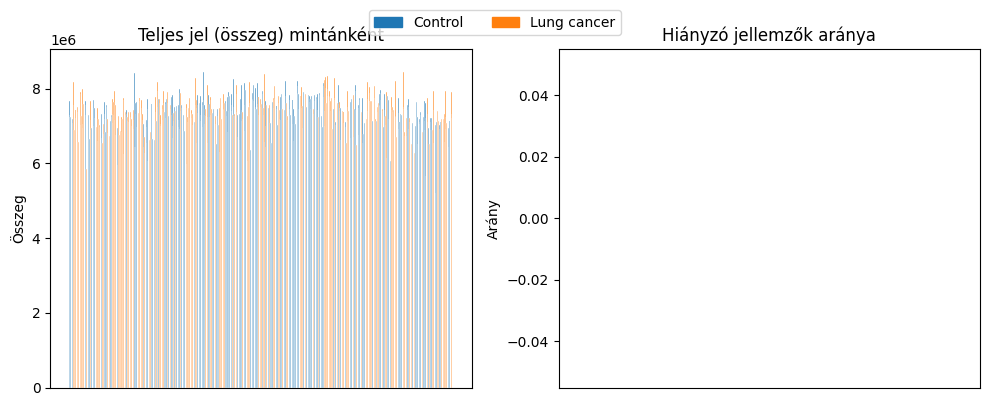

In [4]:
from src.metabolomics_qc import qc_sample_table
from src.metabolomics_plotting import plot_qc_bars

qc = qc_sample_table(X_raw)
print(qc.describe())
fig = plot_qc_bars(qc, meta, hue_col="class_label")
fig.savefig("qc_overview_mtbls28.png", dpi=150, bbox_inches="tight")


### Preprocessing

In [5]:
from src.metabolomics_preprocessing import nmr_style_matrices, preprocess_feature_matrix

blocks = nmr_style_matrices(X_raw, impute_first=True)
for k, df in blocks.items():
    print(k, df.shape)
X_pareto = blocks["X_pareto"]
X_log = blocks["X_log"]

X_proc, steps = preprocess_feature_matrix(X_raw)
print("Klasszikus LC–MS lépések:", " → ".join(steps))
X_proc.head()


X_raw (1005, 3166)
X_pqn (1005, 3166)
X_log (1005, 3166)
X_pareto (1005, 3166)
Klasszikus LC–MS lépések: median_sample_norm → impute_half_min → log1p → pareto_columns


,pos__mz=61.04058; rt=23.70,pos__mz=65.03961; rt=194.32,pos__mz=67.05510; rt=129.65,pos__mz=69.03440; rt=134.59,pos__mz=69.07064; rt=168.14,pos__mz=69.07063; rt=46.95,pos__mz=70.01279; rt=14.95,pos__mz=71.04989; rt=28.98,pos__mz=72.08143; rt=105.95,pos__mz=73.06558; rt=167.92,...,neg__mz=654.18771; rt=67.03,neg__mz=656.15980; rt=203.71,neg__mz=675.16625; rt=65.13,neg__mz=675.96943; rt=30.26,neg__mz=676.17060; rt=65.25,neg__mz=681.98642; rt=129.46,neg__mz=816.99797; rt=74.89,neg__mz=829.27415; rt=159.14,neg__mz=830.27806; rt=59.04,neg__mz=835.29163; rt=159.46
sample_id,,,,,,,,,,,,,,,,,,,,,
000801,-0.248868,-0.360994,0.193660,0.098805,-0.379142,1.147101,-0.426143,0.874628,-0.024283,-0.323829,...,-0.612901,0.548035,-0.531445,0.263013,-0.411286,1.103103,0.584336,-0.174954,-0.621487,0.475356
000901,0.752984,-0.329093,0.051732,0.071984,0.168638,-0.294499,-0.399337,0.222104,0.622867,0.074509,...,-0.611275,-0.346408,-0.537859,0.144652,-0.403738,0.710903,0.967452,0.161495,-0.060305,0.606356
001001,0.777603,2.197781,0.208522,0.425780,0.387521,-0.042833,-0.040922,0.712561,-0.472975,0.340552,...,-0.616297,-0.252389,-0.526669,-0.698503,-0.414413,-0.822419,0.927149,0.304728,0.284632,1.283011
001101,-0.904921,-0.360162,0.134744,1.067981,-1.218575,-0.177917,-0.854149,0.573233,1.123468,-0.605034,...,-0.614683,-0.314993,-0.522737,0.176757,-0.409151,-0.111489,-0.564600,-0.827388,-0.484267,-0.778742
001201,0.890104,-0.282187,-0.101449,0.074048,-0.212110,-0.164032,-0.236919,-0.518318,-0.546866,-0.033378,...,-0.617482,0.237696,-0.551528,-0.015762,-0.420836,0.832534,1.956994,0.932708,0.659003,1.467999


## 3. PCA és explroatív adatstruktúra


Magyarázott variancia (első 5 PC): [0.1116, 0.0665, 0.062, 0.0365, 0.0342]


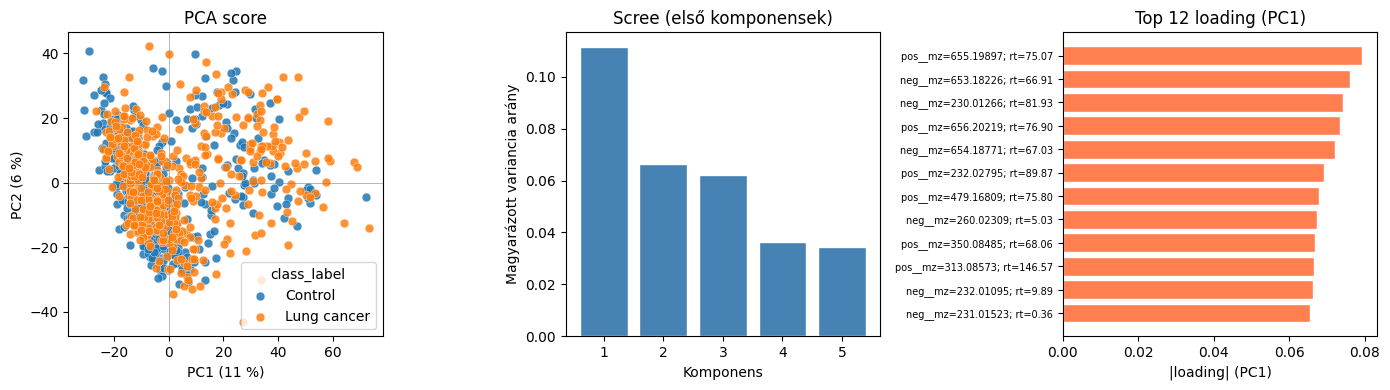

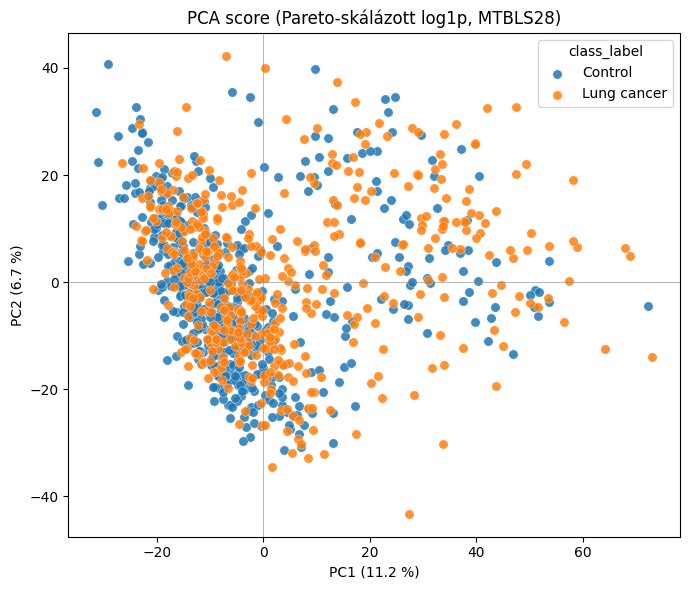

In [6]:
from src.metabolomics_multivariate import fit_pca
from src.metabolomics_plotting import plot_pca_multipanel, plot_pca_scores

pca_out = fit_pca(X_pareto, n_components=5, standardize=False)
scores = pca_out["scores"]
var = pca_out["explained_variance_ratio"]
print("Magyarázott variancia (első 5 PC):", [round(float(v), 4) for v in var])

fig = plot_pca_multipanel(pca_out, meta, hue_col="class_label")
fig.savefig("pca_multipanel_mtbls28.png", dpi=150, bbox_inches="tight")

fig2 = plot_pca_scores(
    scores, meta,
    pc_x="PC1", pc_y="PC2",
    hue_col="class_label",
    explained=var,
    title="PCA score (Pareto-skálázott log1p, MTBLS28)",
)
fig2.savefig("pca_scores_mtbls28.png", dpi=150, bbox_inches="tight")


## 4. Exploratív feature selection és biomarkerjelölt-keresés
### 4.1 Univariáns elemzés, FDR, volcano plot

                         feature  mean_Lung cancer  mean_Control    log2fc  \
0    pos__mz=264.12152; rt=23.31          5.356432      4.576635  0.226985   
1    neg__mz=308.09849; rt=18.93          5.843039      5.500399  0.087183   
2    pos__mz=372.92326; rt=27.98          5.550502      6.043579 -0.122785   
3    pos__mz=615.03532; rt=34.29          4.897979      5.631643 -0.201369   
4    pos__mz=423.00849; rt=33.92          6.392827      7.016368 -0.134270   
5    pos__mz=252.97452; rt=32.25          6.926113      7.429240 -0.101169   
6   pos__mz=340.11926; rt=319.58          5.129134      5.558804 -0.116059   
7    pos__mz=215.01722; rt=32.24          9.895917     10.427071 -0.075429   
8   neg__mz=239.09189; rt=336.89          5.863775      6.472963 -0.142597   
9     pos__mz=407.03447; rt=3.72          5.690939      6.247701 -0.134659   
10   pos__mz=424.01276; rt=34.37          4.709354      5.155416 -0.130560   
11   pos__mz=429.02268; rt=33.90          5.051491      5.578264

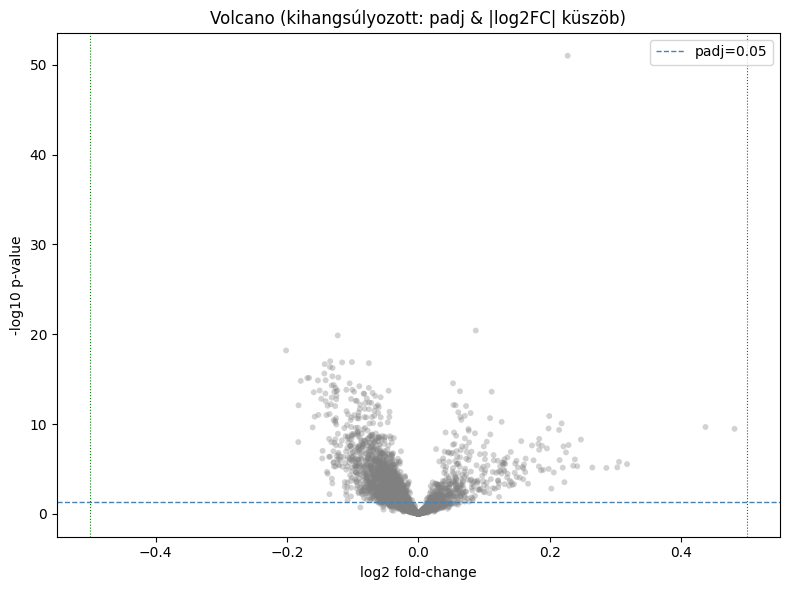

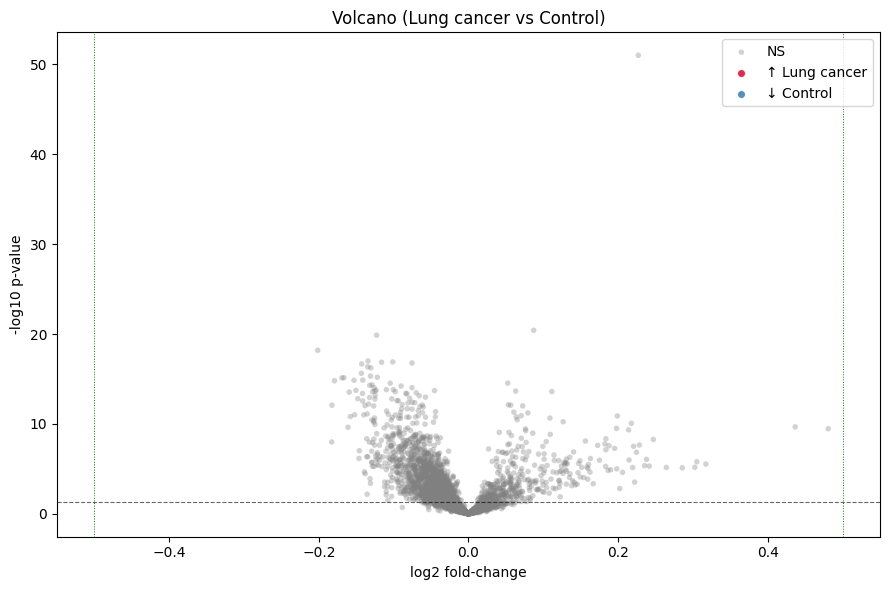

In [7]:
# MTBLS28: minden minta egy vizeletes profil; csoport = class_label
metab = meta

from src.metabolomics_univariate import differential_analysis
from src.metabolomics_plotting import plot_volcano, plot_volcano_categorized

diff = differential_analysis(
    X_log,
    metab["class_label"],
    group_a="Lung cancer",
    group_b="Control",
    include_cohen_d=True,
)
print(diff.head(15))
fig = plot_volcano(diff, alpha=0.05, fc_thresh=0.5)
fig.savefig("volcano_lung_cancer_vs_control_mtbls28.png", dpi=150, bbox_inches="tight")
figc = plot_volcano_categorized(
    diff,
    group_up="Lung cancer",
    group_down="Control",
    alpha=0.05,
    fc_thresh=0.5,
)
figc.savefig("volcano_categorized_mtbls28.png", dpi=150, bbox_inches="tight")



### 4.2 Top feature heatmap


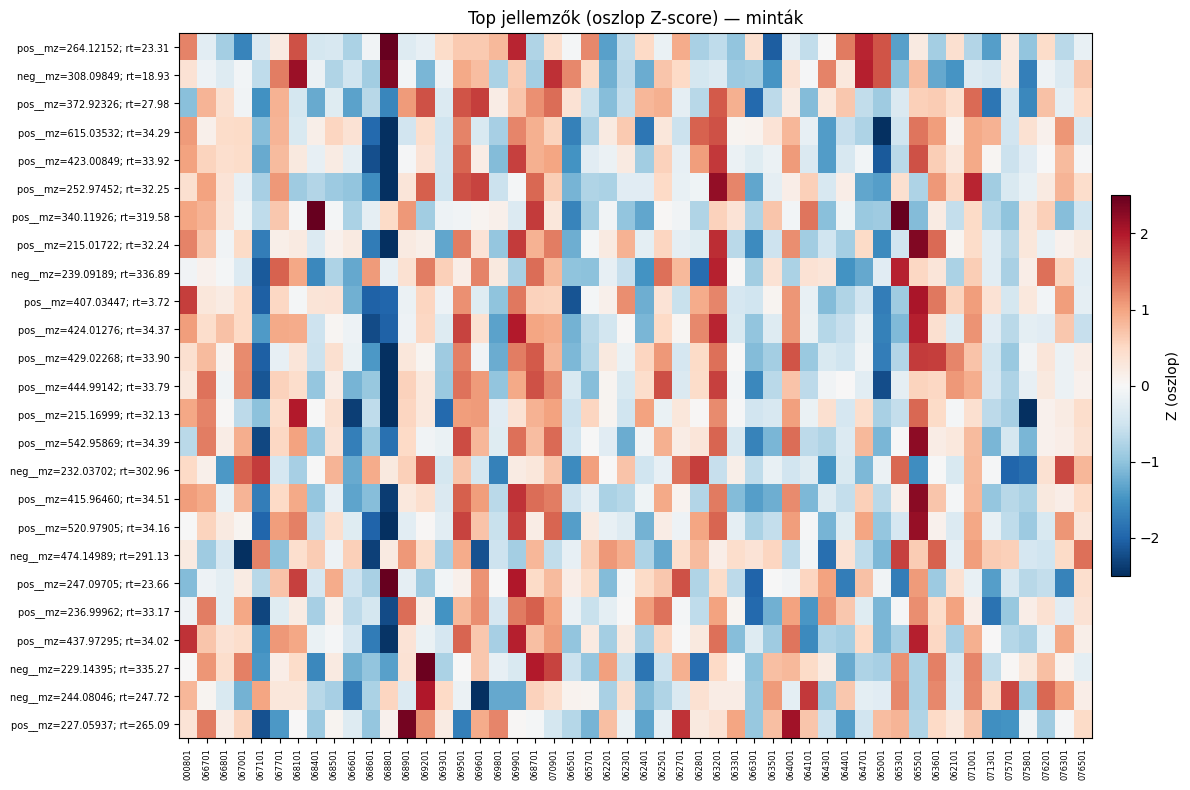

In [8]:
from src.metabolomics_plotting import plot_top_features_heatmap

top_n = 25
top_feats = diff.nsmallest(top_n, "padj")["feature"].tolist()
fig = plot_top_features_heatmap(
    X_pareto,
    top_feats,
    metab,
    group_col="class_label",
    max_samples=50,
)
fig.savefig("heatmap_top_features_mtbls28.png", dpi=150, bbox_inches="tight")


### 4.3 PLS-DA, VIP és S-plot


pos__mz=264.12152; rt=23.31     4.300867
neg__mz=308.09849; rt=18.93     3.243606
pos__mz=332.09634; rt=23.39     2.882242
pos__mz=243.10048; rt=3.75      2.807744
neg__mz=126.90693; rt=8.64      2.739464
pos__mz=247.09705; rt=23.66     2.691072
neg__mz=613.35956; rt=337.91    2.536442
neg__mz=213.08713; rt=98.69     2.505154
neg__mz=290.08851; rt=19.40     2.470099
pos__mz=370.05260; rt=21.63     2.437504
Name: VIP, dtype: float64


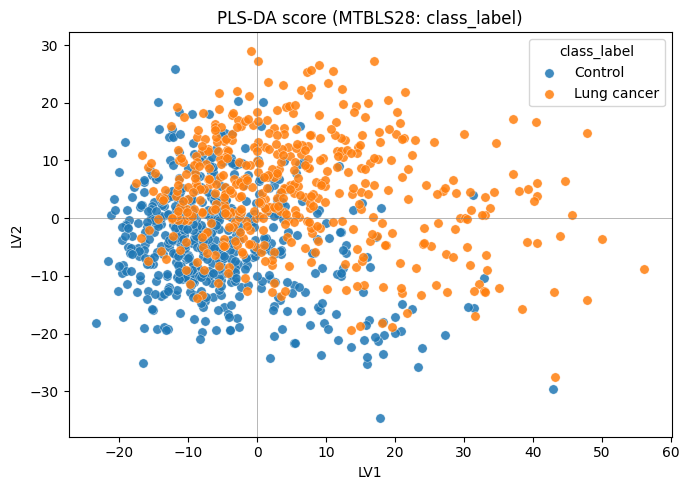

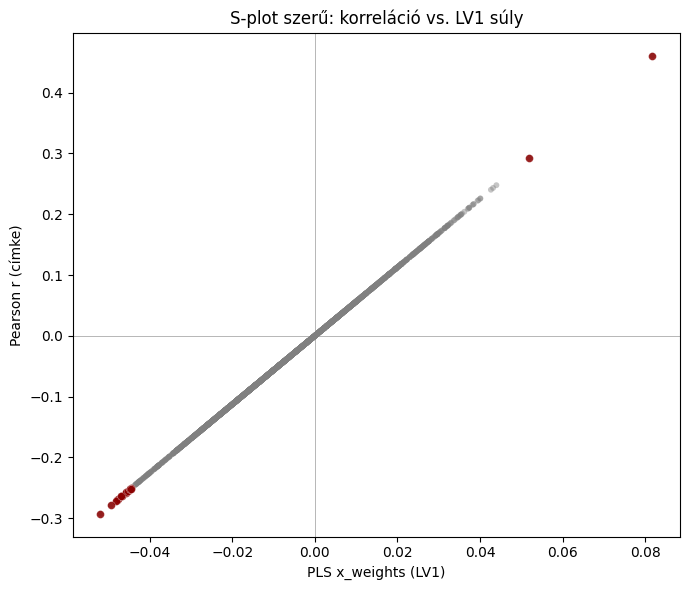

In [9]:
from src.metabolomics_multivariate import fit_plsda_multiclass
from src.metabolomics_plotting import plot_s_plot_lv1
import matplotlib.pyplot as plt

plsda = fit_plsda_multiclass(
    X_pareto,
    metab["class_label"],
    n_components=3,
    scale=True,
)
s_pls = plsda["scores"]
vip = plsda["vip"]
print(vip.nlargest(10))

fig, ax = plt.subplots(figsize=(7, 5))
for lab in metab["class_label"].dropna().unique():
    m = metab["class_label"] == lab
    ax.scatter(s_pls.loc[m, "LV1"], s_pls.loc[m, "LV2"], label=str(lab), s=45, alpha=0.85, edgecolors="white", linewidths=0.3)
ax.set_xlabel("LV1")
ax.set_ylabel("LV2")
ax.set_title("PLS-DA score (MTBLS28: class_label)")
ax.legend(title="class_label")
ax.axhline(0, color="gray", lw=0.4)
ax.axvline(0, color="gray", lw=0.4)
fig.tight_layout()
fig.savefig("plsda_scores_mtbls28.png", dpi=150, bbox_inches="tight")

w1 = plsda["model"].pls.x_weights_[:, 0]
figs = plot_s_plot_lv1(X_pareto, metab["class_label"], "Lung cancer", w1)
figs.savefig("splot_lv1_mtbls28.png", dpi=150, bbox_inches="tight")


### 4.4 Random Forest feature importance

In [10]:
from src.metabolomics_ml import random_forest_feature_importance

imp = random_forest_feature_importance(
    X_pareto,
    metab["class_label"],
    "Lung cancer",
    n_estimators=300,
)
print(imp.head(20))


pos__mz=264.12152; rt=23.31     0.014014
pos__mz=486.25713; rt=125.04    0.005276
neg__mz=308.09849; rt=18.93     0.005106
neg__mz=441.16137; rt=307.95    0.003726
pos__mz=340.11926; rt=319.58    0.003635
pos__mz=656.20175; rt=3.99      0.003346
neg__mz=208.06462; rt=94.76     0.003195
pos__mz=584.26707; rt=131.43    0.002929
neg__mz=122.02489; rt=22.88     0.002905
pos__mz=204.13455; rt=48.37     0.002840
neg__mz=613.35956; rt=337.91    0.002806
pos__mz=274.09314; rt=132.72    0.002789
pos__mz=561.34320; rt=328.95    0.002784
pos__mz=478.17208; rt=1.24      0.002484
neg__mz=126.90693; rt=8.64      0.002376
pos__mz=243.10048; rt=3.75      0.002375
pos__mz=296.12766; rt=309.45    0.002338
neg__mz=239.09189; rt=336.89    0.002287
pos__mz=638.36088; rt=328.13    0.002279
pos__mz=252.97452; rt=32.25     0.002274
Name: importance, dtype: float64


## 5. Validált ML pipeline-ok: preprocessing, feature selection és modell-összehasonlítás
### 5.1 Cél és bemenet
Cél: **Lung cancer vs Control** klasszifikáció validált, leakage-mentes pipeline-okkal.

Bemenet: `X_raw`, `y = meta["class_label"]`.
Pozitív osztály: `Lung cancer`, negatív osztály: `Control`.

A validált ML rész elsődlegesen **nem** az előre számolt `X_pareto`-ból indul, hanem közvetlenül `X_raw`-ból.

### 5.2 Train / validation / test split
- 70% train
- 15% validation
- 15% test


In [ ]:
from src.metabolomics_ml import make_train_valid_test_split

X_train, X_valid, X_test, y_train, y_valid, y_test = make_train_valid_test_split(
    X_raw,
    metab["class_label"],
    positive_label="Lung cancer",
    test_size=0.15,
    valid_size=0.15,
    random_state=42,
)

split_info = {
    "n_total": len(X_raw),
    "n_train": len(X_train),
    "n_valid": len(X_valid),
    "n_test": len(X_test),
}
print(split_info)


### 5.5 Modellek
- Lasso (L1 logistic regression)
- Ridge (L2 logistic regression)
- Random Forest
- XGBoost (ha elérhető)
- Neural Network (TensorFlow MLP)



In [ ]:
from src.metabolomics_ml import build_models

k_values = (50, 100, 200, 500)
selector_method = "kbest"
sample_normalization = "median"
scaler = "standard"
variance_threshold = 0.0

model_pool = build_models(random_state=42)
print("Modellek:", sorted(model_pool.keys()))

### 5.6 Modellek tanítása, validáció és végső test értékelés
Lépések:
1. minden modell × `k` kombináció futtatása train adaton,
2. preprocessing és feature selection *
3. validációs ROC-AUC alapján legjobb konfiguráció választása modellenként,
4. legjobb konfiguráció újratanítása train+valid adaton,
5. egyszeri final értékelés test adaton.

#### * Preprocessing és feature-selection
- missing value imputáció (median)
- mintánkénti normalizálás
- `log1p` transzformáció
- alacsony varianciájú feature-ök kiszűrése
- skálázás

`fit`: csak train adaton, `transform`: validation/test adaton.

- `SelectKBest(f_classif)` több `k` értékkel
- opcionálisan L1-logisztikus regresszió alapú szelekció




In [ ]:
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd

from src.metabolomics_ml import (
    build_model_pipeline,
    build_preprocess_pipeline,
    build_feature_selector,
    evaluate_binary_classifier,
    extract_model_features
)

output_dir = Path("outputs/ml_benchmark_mtbls28")
(output_dir / "confusion_matrices").mkdir(parents=True, exist_ok=True)
(output_dir / "top_features").mkdir(parents=True, exist_ok=True)

metrics_rows = []
pred_frames = []
selected_frames = []
best_estimators = {}

for model_name, base_model in model_pool.items():
    best_auc = -np.inf
    best_k = None

    for k in k_values:
        k_eff = int(min(k, X_train.shape[1]))
        if k_eff <= 0:
            continue

        preprocess = build_preprocess_pipeline(
            sample_normalization=sample_normalization,
            scaler=scaler,
            variance_threshold=variance_threshold,
        )
        selector = build_feature_selector(method=selector_method, k=k_eff, random_state=42)
        pipe = build_model_pipeline(preprocess, selector, deepcopy(base_model))
        pipe.fit(X_train, y_train)

        val_metrics, _ = evaluate_binary_classifier(
            pipe,
            X_valid,
            y_valid,
            dataset_name="validation",
            model_name=model_name,
        )
        if val_metrics["roc_auc"] > best_auc:
            best_auc = val_metrics["roc_auc"]
            best_k = k_eff

    if best_k is None:
        continue

    preprocess = build_preprocess_pipeline(
        sample_normalization=sample_normalization,
        scaler=scaler,
        variance_threshold=variance_threshold,
    )
    selector = build_feature_selector(method=selector_method, k=best_k, random_state=42)
    best_pipe = build_model_pipeline(preprocess, selector, deepcopy(base_model))

    X_train_valid = pd.concat([X_train, X_valid], axis=0)
    y_train_valid = pd.concat([y_train, y_valid], axis=0)
    best_pipe.fit(X_train_valid, y_train_valid)

    val_metrics, val_preds = evaluate_binary_classifier(
        best_pipe, X_valid, y_valid, dataset_name="validation", model_name=model_name
    )
    val_metrics["k"] = best_k

    test_metrics, test_preds = evaluate_binary_classifier(
        best_pipe, X_test, y_test, dataset_name="test", model_name=model_name
    )
    test_metrics["k"] = best_k

    metrics_rows.extend([val_metrics, test_metrics])
    pred_frames.extend([val_preds, test_preds])
    best_estimators[model_name] = best_pipe

    feat_df = extract_model_features(
        best_pipe,
        original_feature_names=list(X_raw.columns),
        model_name=model_name,
        top_n=30,
    )
    feat_df["k"] = best_k
    selected_frames.append(feat_df)

metrics = pd.DataFrame(metrics_rows).sort_values(["model", "dataset"]).reset_index(drop=True)
predictions = pd.concat(pred_frames, ignore_index=True)
selected_features = pd.concat(selected_frames, ignore_index=True)

metrics.to_csv(output_dir / "ml_metrics.csv", index=False)
predictions.to_csv(output_dir / "ml_predictions.csv", index=False)
selected_features.to_csv(output_dir / "ml_selected_features.csv", index=False)



### 5.7 ROC-görbék és confusion matrixok
Publikációs jellegű összehasonlító ábrák mentése minden modellre.

In [ ]:
from src.metabolomics_ml import (
    plot_metric_comparison,
    plot_roc_curves,
    plot_confusion_matrices
)

plot_metric_comparison(metrics, metric="roc_auc", output_path=output_dir / "metric_comparison_roc_auc.png")
plot_metric_comparison(metrics, metric="f1", output_path=output_dir / "metric_comparison_f1.png")
plot_roc_curves(predictions, output_path=output_dir / "roc_curves_test.png")
plot_confusion_matrices(metrics, output_dir=output_dir / "confusion_matrices")




### 5.8 ML-alapú top feature-ök
A `feature_summary` tábla kombinálja az univariáns, PLS-DA VIP, exploratív RF és validált ML feature-információkat.

Javasolt oszlopok:
- `feature`
- `univariate_rank`
- `plsda_vip_rank`
- `rf_expl_rank`
- `lasso_selected`
- `rf_ml_importance`
- `xgboost_importance`

In [ ]:
from src.metabolomics_ml import plot_top_features

plot_top_features(selected_features, top_n=20)

metrics

# Integrált feature tábla az exploratív és validált eredményekből
univar_rank = diff[["feature", "padj"]].copy().sort_values("padj").reset_index(drop=True)
univar_rank["univariate_rank"] = np.arange(1, len(univar_rank) + 1)
univar_rank = univar_rank[["feature", "univariate_rank"]]

vip_rank = vip.sort_values(ascending=False).rename("vip").reset_index()
vip_rank.columns = ["feature", "vip"]
vip_rank["plsda_vip_rank"] = np.arange(1, len(vip_rank) + 1)
vip_rank = vip_rank[["feature", "plsda_vip_rank"]]

rf_expl_rank = imp.sort_values(ascending=False).rename("rf_expl_importance").reset_index()
rf_expl_rank.columns = ["feature", "rf_expl_importance"]
rf_expl_rank["rf_expl_rank"] = np.arange(1, len(rf_expl_rank) + 1)
rf_expl_rank = rf_expl_rank[["feature", "rf_expl_rank"]]

sel = selected_features.copy()
sel["lasso_selected"] = np.where(sel["model"] == "lasso", 1, 0)
sel_lasso = sel.groupby("feature", as_index=False)["lasso_selected"].max()

rf_ml = sel[sel["model"] == "random_forest"][["feature", "importance"]].rename(
    columns={"importance": "rf_ml_importance"}
)
xgb_ml = sel[sel["model"] == "xgboost"][["feature", "importance"]].rename(
    columns={"importance": "xgboost_importance"}
)

feature_summary = (
    univar_rank
    .merge(vip_rank, on="feature", how="outer")
    .merge(rf_expl_rank, on="feature", how="outer")
    .merge(sel_lasso, on="feature", how="left")
    .merge(rf_ml, on="feature", how="left")
    .merge(xgb_ml, on="feature", how="left")
)
feature_summary["lasso_selected"] = feature_summary["lasso_selected"].fillna(0).astype(int)

feature_summary = feature_summary.sort_values(
    ["univariate_rank", "plsda_vip_rank", "rf_expl_rank"],
    na_position="last",
).reset_index(drop=True)

feature_summary.head(30)